In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

zip_path = "/content/drive/MyDrive/NammaRetina/processed.zip"

print(os.path.exists(zip_path))

True


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/NammaRetina/processed.zip"
extract_path = "/content/processed"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os

print(os.listdir("/content/processed"))

['processed']


In [ ]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/NammaRetina/processed.zip") as z:
    print(z.namelist()[:10])

['processed/', 'processed/preprocessing_comparison.png', 'processed/test.csv', 'processed/test_images/', 'processed/test_images/e4dcca36ceb4.png', 'processed/test_images/e4e343eaae2a.png', 'processed/test_images/e4f12411fd85.png', 'processed/test_images/e50b0174690d.png', 'processed/test_images/e5197d77ec68.png', 'processed/test_images/e529c5757d64.png']


In [ ]:
import os

print(os.listdir("/content/processed/processed"))

['valid.csv', 'train_images', 'test_images', 'val_images', 'train.csv', 'test.csv', 'preprocessing_comparison.png']


In [ ]:
import os

base = "/content/processed/processed"

train = len(os.listdir(base + "/train_images"))
val = len(os.listdir(base + "/val_images"))
test = len(os.listdir(base + "/test_images"))

print("Train:", train)
print("Validation:", val)
print("Test:", test)


Train: 2930
Validation: 366
Test: 366


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/processed/processed/train.csv")

train_df.head()

,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [ ]:
train_df["diagnosis"].value_counts().sort_index()

,count
diagnosis,
0,1434
1,300
2,808
3,154
4,234


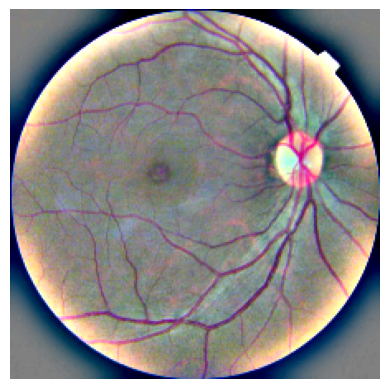

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

folder = "/content/processed/processed/train_images"

img_name = os.listdir(folder)[0]

img = Image.open(os.path.join(folder, img_name))

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import os
import random

folder = "/content/processed/processed/train_images"

for img_name in random.sample(os.listdir(folder), 10):
    img = Image.open(os.path.join(folder, img_name))
    print(img_name, img.size, img.mode)

73ba798fee25.png (224, 224) RGB
4958bfcc9f38.png (224, 224) RGB
a7b03e58a6e1.png (224, 224) RGB
913490237ad4.png (224, 224) RGB
1db0393cdbc1.png (224, 224) RGB
7ee6de71c140.png (224, 224) RGB
d1fa0f744620.png (224, 224) RGB
bab776139279.png (224, 224) RGB
66393d8c60ba.png (224, 224) RGB
6089fa333013.png (224, 224) RGB


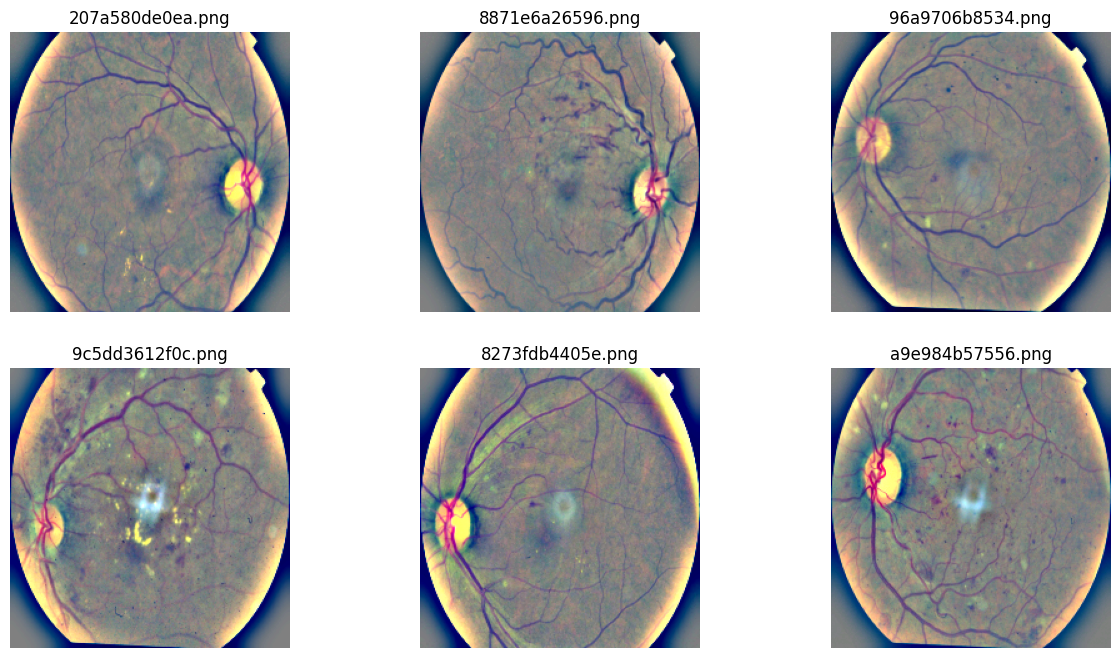

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

folder = "/content/processed/processed/train_images"

imgs = random.sample(os.listdir(folder), 6)

plt.figure(figsize=(15,8))

for i, img_name in enumerate(imgs):
    img = Image.open(os.path.join(folder,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [ ]:
import pandas as pd
import os

train_df = pd.read_csv("/content/processed/processed/train.csv")

missing = []

for img_id in train_df["id_code"]:
    path = f"/content/processed/processed/train_images/{img_id}.png"

    if not os.path.exists(path):
        missing.append(img_id)

print("Missing images:", len(missing))

Missing images: 0


In [ ]:
import numpy as np
from PIL import Image
import random
import os

folder = "/content/processed/processed/train_images"

mins = []
maxs = []
means = []

for img_name in random.sample(os.listdir(folder), 20):
    img = np.array(Image.open(os.path.join(folder, img_name)))

    mins.append(img.min())
    maxs.append(img.max())
    means.append(img.mean())

print("Minimum pixel:", min(mins))
print("Maximum pixel:", max(maxs))
print("Average pixel:", np.mean(means))

Minimum pixel: 0
Maximum pixel: 255
Average pixel: 128.2759254092262


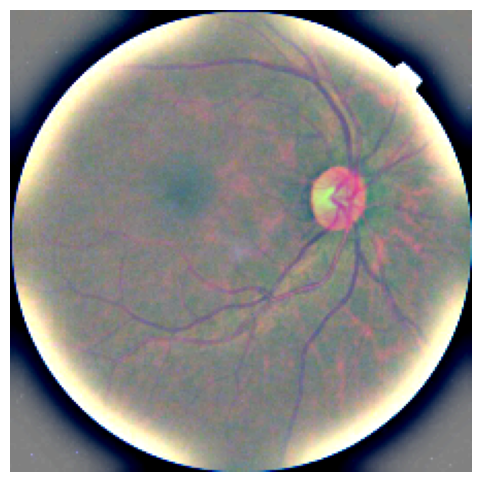

In [ ]:
img = Image.open("/content/processed/processed/train_images/" + random.choice(os.listdir(folder)))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

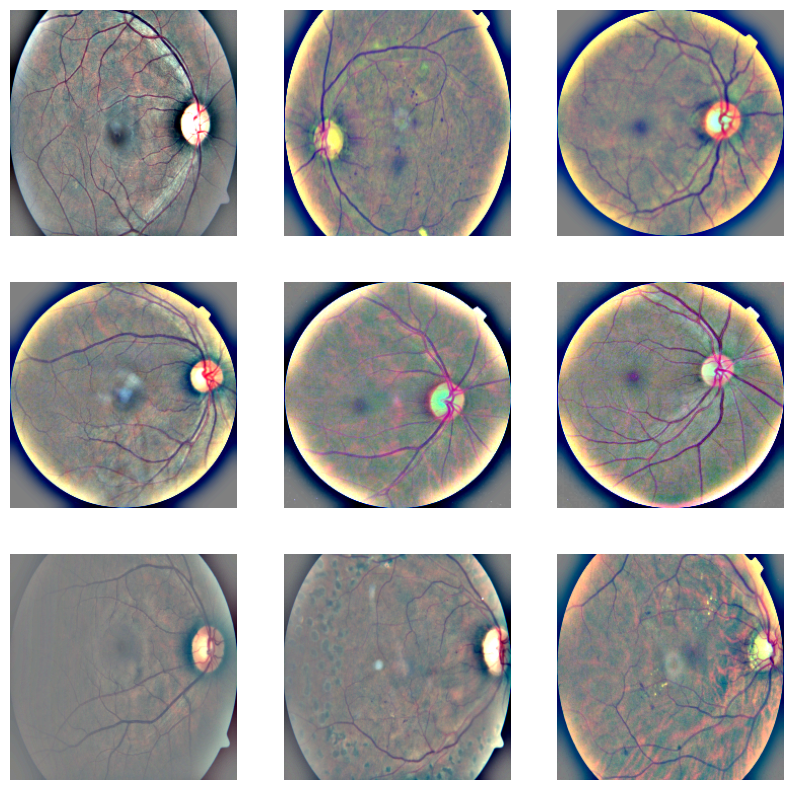

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random

train_dir = "/content/processed/processed/train_images"

imgs = random.sample(os.listdir(train_dir), 9)

plt.figure(figsize=(10,10))

for i,img_name in enumerate(imgs):
    img = cv2.imread(os.path.join(train_dir,img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()